<a href="https://colab.research.google.com/github/athitthiyan/Learning_Gen_AI/blob/main/Researcher_Supervisor_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Researcher → Supervisor → Writer (LangGraph)

A small multi-agent graph:
- **Supervisor** decides who acts next (researcher / writer / FINISH).
- **Researcher** searches the web with Tavily.
- **Writer** drafts a report from the research notes.

Human-in-the-loop is added via a **breakpoint** (`interrupt_before=["writer"]`) so you can
review the research before the writer runs.


In [1]:
# 1) Install dependencies
# langchain-tavily replaces the deprecated TavilySearchResults from langchain_community.
%pip install -qU langgraph langchain-groq langchain-tavily langchain-core pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.13.4 which is incompatible.


In [2]:
# 2) API keys (set as environment variables; prompted if not already set)
import os, getpass

if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Groq API key: ")
if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API key: ")

Groq API key: ··········
Tavily API key: ··········


In [3]:
# 3) Shared state and the Supervisor's decision schema
import operator
from typing import Annotated, List, TypedDict, Literal
from pydantic import BaseModel, Field

# The State object that travels through the graph
class AgentState(TypedDict):
    task: str
    research_notes: Annotated[List[str], operator.add]
    draft: str
    next_node: str
    retry_count: int
    revision_feedback: str

# Schema for the Supervisor to follow
class Router(BaseModel):
    """Decide which worker to call next."""
    next_worker: Literal["researcher", "writer", "FINISH"] = Field(description="The next node to act")
    instructions: str = Field(description="Specific instructions for the worker")
    is_critical: bool = Field(description="If True, system will pause for human review")

In [4]:
# 4) The LLM, the tools, and the three node functions
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch   # was: langchain_community ... TavilySearchResults (deprecated)

# Llama 3.3 70B as the "brain" (Supervisor + Writer). model=, not model_name=
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
search_tool = TavilySearch(max_results=2)    # was: TavilySearchResults(k=2)  -> wrong kwarg


def researcher(state: AgentState):
    print("\U0001F680 Researcher is digging...")
    query = state["task"]
    results = search_tool.invoke({"query": query})
    print(results)
    return {"research_notes": [str(results)], "retry_count": 0}


def writer(state: AgentState):
    print("\u270D\uFE0F Writer is composing...")
    context = "\n".join(state["research_notes"])
    res = llm.invoke(f"Write a clear, well-structured report on '{state['task']}' using these notes:\n{context}")
    return {"draft": res.content}


def supervisor(state: AgentState):
    print("\U0001F9E0 Supervisor is reviewing state...")
    structured_llm = llm.with_structured_output(Router)

    n_notes = len(state.get("research_notes", []))
    has_draft = bool(state.get("draft"))

    # Explicit routing rules so the model can actually reach FINISH
    prompt = f"""
    You are a supervisor coordinating a researcher and a writer.

    Routing rules (follow exactly):
    - If there are NO research notes yet -> next_worker = "researcher".
    - If there ARE research notes but NO draft has been written yet -> next_worker = "writer".
    - If a draft already exists -> next_worker = "FINISH".

    Current state:
    - Task: {state['task']}
    - Research notes collected: {n_notes}
    - Draft already written: {"yes" if has_draft else "no"}

    Return next_worker, short instructions for that worker, and is_critical.
    """
    print(f"Supervisor sees {n_notes} notes and draft length {len(state.get('draft', ''))}")
    decision = structured_llm.invoke(prompt)

    next_worker = decision.next_worker
    # Safety guard: once a draft exists we must finish, so the writer can never loop forever.
    if has_draft:
        next_worker = "FINISH"

    return {
        "next_node": next_worker,
        "revision_feedback": decision.instructions,
    }

In [5]:
# 5) Build the graph with persistence (recovery) and a breakpoint (pause)
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(AgentState)

builder.add_node("supervisor", supervisor)
builder.add_node("researcher", researcher)
builder.add_node("writer", writer)

builder.set_entry_point("supervisor")

builder.add_conditional_edges(
    "supervisor",
    lambda x: x["next_node"],
    {"researcher": "researcher", "writer": "writer", "FINISH": END},
)

builder.add_edge("researcher", "supervisor")
builder.add_edge("writer", "supervisor")

memory = MemorySaver()
graph = builder.compile(
    checkpointer=memory,
    interrupt_before=["writer"],  # PAUSE: human reviews the research before writing starts
)

## Visualize the graph
LangGraph can render the compiled graph as a diagram inside IPython/Jupyter.

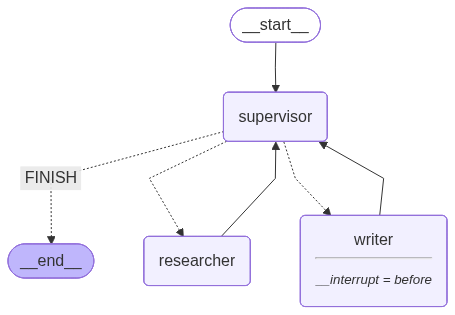

In [6]:
# Render the LangGraph architecture as a diagram (run AFTER the graph is compiled)
from IPython.display import Image, display

try:
    # draw_mermaid_png() uses the mermaid.ink web service (needs internet),
    # or a local graphviz if installed.
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Offline fallback: print the Mermaid source (renders on GitHub, mermaid.live, etc.)
    print(f"PNG render unavailable ({e}). Mermaid source below:\n")
    print(graph.get_graph().draw_mermaid())

In [7]:
# 6) Start execution; it will pause at the breakpoint before the writer runs
config = {"configurable": {"thread_id": "workshop_user_1"}}
initial_input = {
    "task": "Impact of LPU architecture on AI inference speeds",
    "research_notes": [],
    "retry_count": 0,
    "draft": "",
}

print("--- STARTING GRAPH ---")
for event in graph.stream(initial_input, config, stream_mode="values"):
    if event.get("next_node"):
        print(f"Moving to: {event['next_node']}")

snapshot = graph.get_state(config)
if snapshot.next:
    print(f"\n\u23F8\uFE0F SYSTEM PAUSED. Next step is: {snapshot.next}")
    print(f"Feedback from Supervisor: {snapshot.values.get('revision_feedback', '')}")
    print("\nReview the research above, then run the next cell to resume.")

--- STARTING GRAPH ---
🧠 Supervisor is reviewing state...
Supervisor sees 0 notes and draft length 0
Moving to: researcher
🚀 Researcher is digging...
{'query': 'Impact of LPU architecture on AI inference speeds', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.linkedin.com/pulse/future-ai-computing-groqs-language-processing-unit-lpu-maxime-grenu-4n56e', 'title': "Groq's Language Processing Unit (LPU) and Its Revolutionary Impact", 'content': 'With its groundbreaking architecture, the LPU is setting new benchmarks in AI inference, delivering unprecedented speed, energy efficiency, and', 'score': 0.8687491, 'raw_content': None}, {'url': 'https://www.youtube.com/watch?v=ygvVJNqtI-k', 'title': 'Groq LPU: Architecture and Principles of Fast AI Inference - YouTube', 'content': '... LPU features on-chip memory, which significantly boosts data retrieval speeds compared to external memory solutions used by competitors', 'score': 0.8399576, 'raw_conten

In [8]:
# 7) Resume after the pause; runs writer -> supervisor -> FINISH, then prints the report
print("--- RESUMING GRAPH ---\n")
for event in graph.stream(None, config, stream_mode="values"):
    if event.get("next_node"):
        print(f"Moving to: {event['next_node']}")

final_state = graph.get_state(config).values
print("\n--- FINAL DRAFT ---\n")
print(final_state.get("draft", "(no draft produced)"))

--- RESUMING GRAPH ---

Moving to: writer
✍️ Writer is composing...
Moving to: writer
🧠 Supervisor is reviewing state...
Supervisor sees 1 notes and draft length 3018
Moving to: FINISH

--- FINAL DRAFT ---

**Impact of LPU Architecture on AI Inference Speeds**

**Introduction**

The increasing demand for artificial intelligence (AI) applications has led to a growing need for faster and more efficient computing architectures. Recently, the Language Processing Unit (LPU) architecture has gained attention for its potential to revolutionize AI computing. This report explores the impact of LPU architecture on AI inference speeds, highlighting its key features and benefits.

**LPU Architecture Overview**

The LPU is a groundbreaking architecture designed specifically for AI workloads. According to recent studies, the LPU has been shown to set new benchmarks in AI inference, delivering unprecedented speed, energy efficiency, and performance. One of the key features of the LPU is its on-chip m

## Optional extension: dynamic human review with `is_critical`

The `Router` schema already returns `is_critical`, but nothing uses it yet. Instead of a *static*
breakpoint that always pauses before the writer, you can pause only when the supervisor flags a step
as critical. Rebuild the graph **without** `interrupt_before`, and have the supervisor raise an
`interrupt` when `is_critical` is True:

```python
from langgraph.types import interrupt

def supervisor(state: AgentState):
    ...
    decision = structured_llm.invoke(prompt)
    if decision.is_critical:
        interrupt({"reason": decision.instructions})   # pauses here; resume with Command(resume=...)
    ...
```

A second idea uses the unused `retry_count`: add a `reviewer` node after `writer` that scores the
draft, and route back to `writer` (incrementing `retry_count`) until it passes or hits a max — a
self-correcting revision loop.